In [3]:
pip install ucimlrepo

In [9]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = df.drop("quality", axis=1) #we drop the column "quality"
Y = df["quality"]
print("\n========= Wine Qualities ========= \n")
print(Y.value_counts())

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


========= Wine Qualities ========= 

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64
{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo 

In [7]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
df = pd.DataFrame(data=wine_quality.data.features, columns=wine_quality.data.feature_names)
df['quality'] = wine_quality.data.targets # Assuming targets are the 'quality' column

X = df.drop("quality", axis=1) #we drop the column "quality"
Y = df["quality"]
print("\n========= Wine Qualities ========= \n")
print(Y.value_counts())
# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


========= Wine Qualities ========= 

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64
{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo 

In [ ]:
X = df.drop("quality", axis=1) #we drop the column "quality"
Y = df["quality"]
print("\n========= Wine Qualities ========= \n")
print(Y.value_counts())

In [ ]:
# bad wine (y=0) : quality <= 5 and good quality (y= 1) otherwise
Y = [0 if val <=5 else 1 for val in Y]

/tmp/ipython-input-503820607.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


<Axes: >

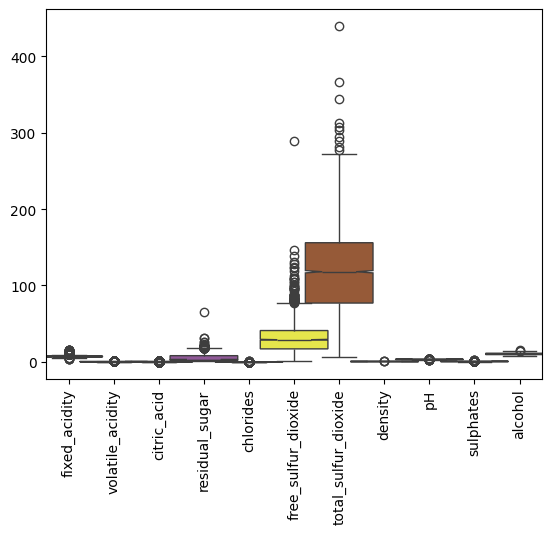

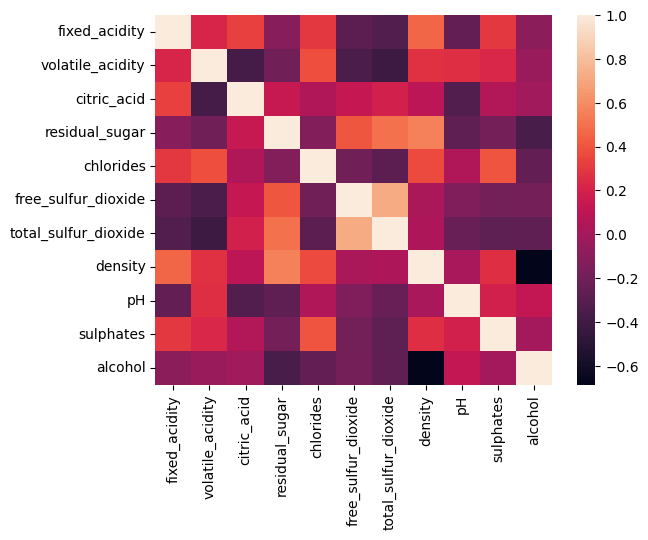

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
ax = plt.gca()
sns.boxplot(data=X,orient="v",palette="Set1",width=1.5, notch=True)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.figure()
corr = X.corr()
sns.heatmap(corr)

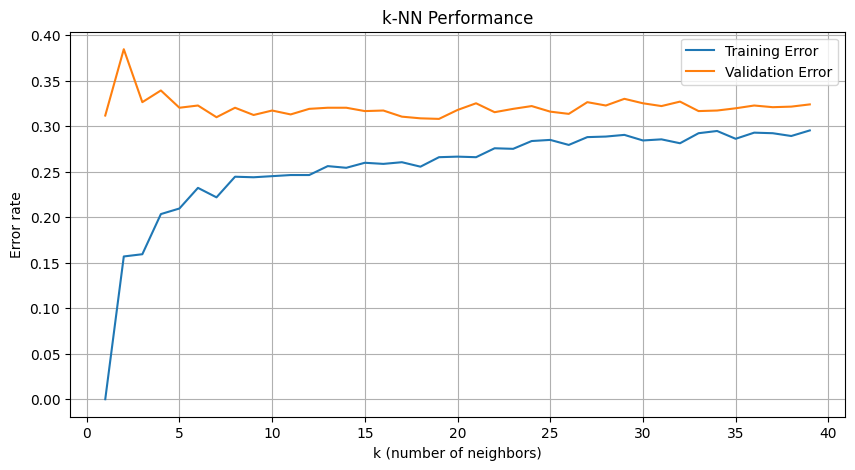

In [10]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Load data
link = "http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
df = pd.read_csv(link, delimiter=";")

# Prepare data
X = df.drop("quality", axis=1)
Y = np.array([0 if q <= 5 else 1 for q in df["quality"]])

# Split
Xa, Xt, Ya, Yt = train_test_split(X, Y, test_size=1/3, stratify=Y)
Xa, Xv, Ya, Yv = train_test_split(Xa, Ya, test_size=0.5, stratify=Ya)

# K values
k_vector = np.arange(1, 40)
error_train = np.zeros(len(k_vector))
error_val = np.zeros(len(k_vector))

# Loop
for i, k in enumerate(k_vector):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(Xa, Ya)

    error_train[i] = 1 - accuracy_score(Ya, clf.predict(Xa))
    error_val[i] = 1 - accuracy_score(Yv, clf.predict(Xv))

# Plot
plt.figure(figsize=(10,5))
plt.plot(k_vector, error_train, label="Training Error")
plt.plot(k_vector, error_val, label="Validation Error")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Error rate")
plt.title("k-NN Performance")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement ou simulation du dataset (remplacer par chargement réel si disponible)
data = {
    'fixed_acidity': [7.4, 7.8, 7.8, 11.2, 7.4],
    'volatile_acidity': [0.7, 0.88, 0.76, 0.28, 0.7],
    'citric_acid': [0, 0, 0.04, 0.56, 0],
    'residual_sugar': [1.9, 2.6, 2.3, 1.9, 1.9],
    'chlorides': [0.076, 0.098, 0.092, 0.075, 0.076],
    'free_sulfur_dioxide': [11, 25, 15, 17, 11],
    'total_sulfur_dioxide': [34, 67, 54, 60, 34],
    'density': [0.9978, 0.9968, 0.997, 0.998, 0.9978],
    'pH': [3.51, 3.2, 3.26, 3.16, 3.51],
    'sulphates': [0.56, 0.68, 0.65, 0.58, 0.56],
    'alcohol': [9.4, 9.8, 9.8, 9.8, 9.4],
    'quality': [5, 5, 5, 6, 5]
}
# If you intend to use this simulated data, you would then create a DataFrame:
# df_simulated = pd.DataFrame(data)
# print(df_simulated)

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                   11                    34   0.9978  3.51       0.56   
1                   25                    67   0.9968  3.20       0.68   
2                   15                    54   0.9970  3.26       0.65   
3                   17                    60   0.9980  3.16       0.58   
4                   11                    34   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2     10.0        5 

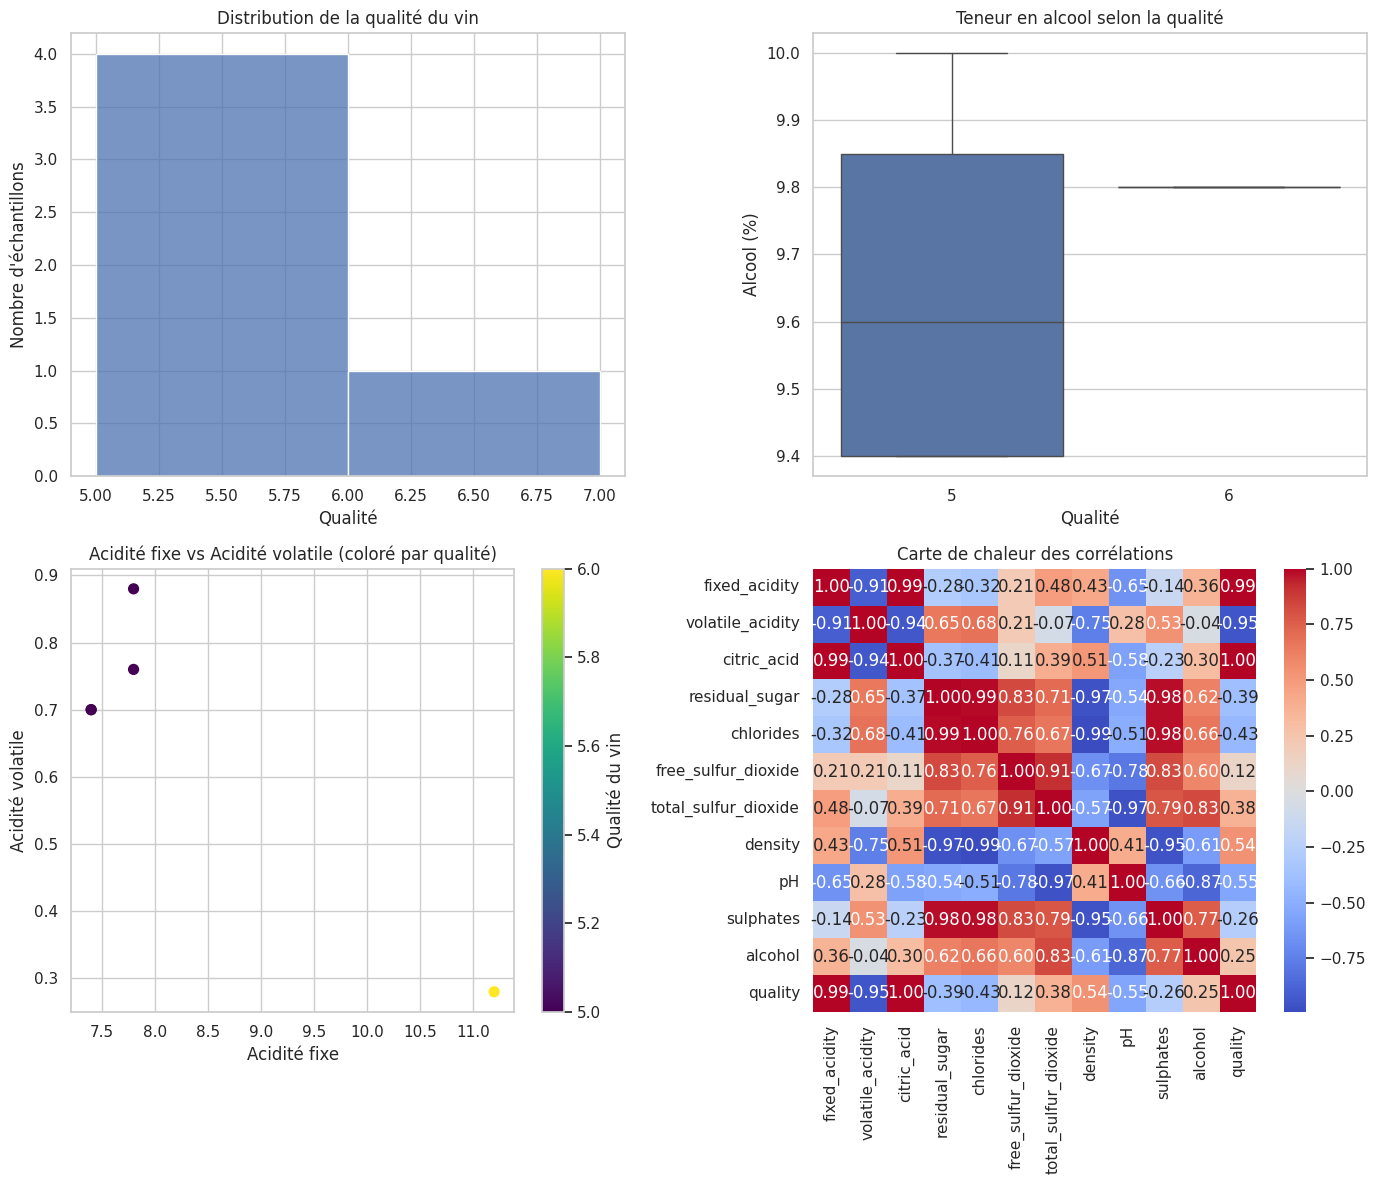

In [13]:
# Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement ou simulation du dataset (remplacer par chargement réel si disponible)
data = {
    'fixed_acidity': [7.4, 7.8, 7.8, 11.2, 7.4],
    'volatile_acidity': [0.7, 0.88, 0.76, 0.28, 0.7],
    'citric_acid': [0, 0, 0.04, 0.56, 0],
    'residual_sugar': [1.9, 2.6, 2.3, 1.9, 1.9],
    'chlorides': [0.076, 0.098, 0.092, 0.075, 0.076],
    'free_sulfur_dioxide': [11, 25, 15, 17, 11],
    'total_sulfur_dioxide': [34, 67, 54, 60, 34],
    'density': [0.9978, 0.9968, 0.997, 0.998, 0.9978],
    'pH': [3.51, 3.20, 3.26, 3.16, 3.51],
    'sulphates': [0.56, 0.68, 0.65, 0.58, 0.56],
    'alcohol': [9.4, 9.8, 10, 9.8, 9.4],
    'quality': [5, 5, 5, 6, 5]
}

wine_df = pd.DataFrame(data)

# Affichage des premières lignes pour vérification
print(wine_df.head())

# Paramétrage seaborn
sns.set(style="whitegrid")

# Création d'une figure avec 4 sous-graphes en 2x2
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Histogramme de la distribution de la qualité du vin
sns.histplot(wine_df['quality'], bins=range(min(wine_df['quality']), max(wine_df['quality'])+2), ax=axs[0,0], kde=False)
axs[0,0].set_title('Distribution de la qualité du vin')
axs[0,0].set_xlabel('Qualité')
axs[0,0].set_ylabel('Nombre d\'échantillons')

# Boxplot de l'alcool en fonction de la qualité
sns.boxplot(x='quality', y='alcohol', data=wine_df, ax=axs[0,1])
axs[0,1].set_title('Teneur en alcool selon la qualité')
axs[0,1].set_xlabel('Qualité')
axs[0,1].set_ylabel('Alcool (%)')

# Nuage de points acidité fixe vs acidité volatile coloré par qualité
scatter = axs[1,0].scatter(wine_df['fixed_acidity'], wine_df['volatile_acidity'], c=wine_df['quality'], cmap='viridis', s=50)
axs[1,0].set_title('Acidité fixe vs Acidité volatile (coloré par qualité)')
axs[1,0].set_xlabel('Acidité fixe')
axs[1,0].set_ylabel('Acidité volatile')
cbar = fig.colorbar(scatter, ax=axs[1,0])
cbar.set_label('Qualité du vin')

# Carte de chaleur des corrélations
corr = wine_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axs[1,1])
axs[1,1].set_title('Carte de chaleur des corrélations')

plt.tight_layout()
plt.show()
